# **Smart Expense & Spending Behavior Analyzer**



# **PHASE 1 — SETUP & DATA UNDERSTANDING**

**STEP 1: Import Core Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
import warnings
warnings.filterwarnings('ignore')

**STEP 2: Load Dataset**

In [ ]:
df = pd.read_csv("/content/Track_Expenses .csv")

print("Dataset Loaded")
print(f"  Shape : {df.shape}")
print(f"  Columns : {df.columns}")

Dataset Loaded
  Shape : (177, 13)
  Columns : Index(['Name', 'Age', 'Monthly income/ Pocket money', 'Expense Amount',
       'Expense Category', 'Payment Method', 'Was this expense necessary?',
       'Date of Expense', 'Do you have a monthly budget?',
       'Monthly Budget Limit (₹) (if not put zero)',
       'Did you exceed your budget?', 'How often do you track your expenses?',
       'Your saving goal'],
      dtype='object')


**STEP 3: Understand Structure**

In [ ]:
print("\n Data Types:")
print(df.dtypes)

print("\n Statistical Summary:")
print(df.describe())


 Data Types:
Name                                          object
Age                                            int64
Monthly income/ Pocket money                   int64
Expense Amount                                 int64
Expense Category                              object
Payment Method                                object
Was this expense necessary?                   object
Date of Expense                               object
Do you have a monthly budget?                 object
Monthly Budget Limit (₹) (if not put zero)     int64
Did you exceed your budget?                   object
How often do you track your expenses?         object
Your saving goal                              object
dtype: object

 Statistical Summary:
              Age  Monthly income/ Pocket money  Expense Amount  \
count  177.000000                    177.000000      177.000000   
mean    22.192090                  16505.084746     1987.124294   
std      3.176144                  17100.060710     4833.83

 **STEP 4: Check Missing Values**

In [ ]:
print("\n Muissing Values:")
print(df.isnull().sum())


 Muissing Values:
Name                                          0
Age                                           0
Monthly income/ Pocket money                  0
Expense Amount                                0
Expense Category                              0
Payment Method                                0
Was this expense necessary?                   0
Date of Expense                               0
Do you have a monthly budget?                 0
Monthly Budget Limit (₹) (if not put zero)    0
Did you exceed your budget?                   0
How often do you track your expenses?         0
Your saving goal                              0
dtype: int64


**STEP 5: Duplicate & Anomaly Check**

In [ ]:
print(f"\n Duplicate Rows : {df.duplicated().sum()}")
print("\n Age Distribution Check:")
print(df['Age'].describe())

anomalies = df[
    (df['Monthly income/ Pocket money'] > 50000) |
    (df['Monthly income/ Pocket money'] < 0)
]

print(f"\n Income Anomalies Found: {len(anomalies)}")

if len(anomalies) > 0:
    print("\n Anomalies:")
    print(anomalies[['Name', 'Monthly income/ Pocket money']])


 Duplicate Rows : 0

 Age Distribution Check:
count    177.000000
mean      22.192090
std        3.176144
min       18.000000
25%       20.000000
50%       22.000000
75%       24.000000
max       43.000000
Name: Age, dtype: float64

 Income Anomalies Found: 2

 Anomalies:
           Name  Monthly income/ Pocket money
38  Vimal kumar                         80000
39   Dilin Nair                        200000


# **PHASE 2 — DATA CLEANING**

**STEP 6: Handle Missing Values**

In [ ]:
df.fillna({'Monthly income/ Pocket money' :
df['Monthly income/ Pocket money'].median(),
           'Expense Category'  : 'Others',
           'Payment Method'    : 'Unknown'
           }, inplace=True)

print("Misssing Values handled")

Misssing Values handled


**STEP 7: Remove Duplicates**

In [ ]:
df.drop_duplicates(inplace=True)

print(f" Duplicates removed -Rows Remanining:, {len(df)}")

 Duplicates removed -Rows Remanining:, 177


**STEP 8: Fix Data Types**

In [ ]:
df['Date of Expense'] = pd.to_datetime(df['Date of Expense'], dayfirst=True, errors='coerce')

print("Date column converted to datetime")

#Age -ensuring integer
df['Age'] = pd.to_numeric(df['Age'], errors='coerce').astype('Int64')
print("Age → Int64")

# Income & Expense — ensure numeric
df['Monthly income/ Pocket money'] = pd.to_numeric(
    df['Monthly income/ Pocket money'], errors='coerce'
)
df['Expense Amount'] = pd.to_numeric(
    df['Expense Amount'], errors='coerce'
)
df['Monthly Budget Limit (₹) (if not put zero)'] = pd.to_numeric(
    df['Monthly Budget Limit (₹) (if not put zero)'], errors='coerce'
).fillna(0)
print("Income, Expense Amount, Budget Limit → numeric (float)")

# Strip whitespace from all string/object columns
str_cols = df.select_dtypes(include='object').columns
df[str_cols] = df[str_cols].apply(lambda col: col.str.strip())
print("Whitespace stripped from all text columns")

# Standardize Yes/No columns to Title Case
yes_no_cols = [
    'Was this expense necessary?',
    'Do you have a monthly budget?',
    'Did you exceed your budget?'
]
for col in yes_no_cols:
    df[col] = df[col].str.title()
print("Yes/No columns standardized to Title Case")

# Standardize category & payment columns
df['Expense Category'] = df['Expense Category'].str.strip().str.title()
df['Payment Method']   = df['Payment Method'].str.strip().str.title()
df['Your saving goal'] = df['Your saving goal'].str.strip().str.title()
print("Expense Category, Payment Method, Saving Goal → Title Case")

# Final type check
print("\n Final Data Types After Fixing:")
print(df.dtypes)


Date column converted to datetime
Age → Int64
Income, Expense Amount, Budget Limit → numeric (float)
Whitespace stripped from all text columns
Yes/No columns standardized to Title Case
Expense Category, Payment Method, Saving Goal → Title Case

 Final Data Types After Fixing:
Name                                                  object
Age                                                    Int64
Monthly income/ Pocket money                           int64
Expense Amount                                         int64
Expense Category                                      object
Payment Method                                        object
Was this expense necessary?                           object
Date of Expense                               datetime64[ns]
Do you have a monthly budget?                         object
Monthly Budget Limit (₹) (if not put zero)             int64
Did you exceed your budget?                           object
How often do you track your expenses?               

**STEP 9: Handle Outliers — IQR Method**

In [ ]:
outlier_coulmns = [
    'Expense Amount',
    'Monthly income/ Pocket money',
    'Monthly Budget Limit (₹) (if not put zero)'
]

before= len(df)

for col in outlier_coulmns:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5 * iqr
  upper_bound = q3 + 1.5 * iqr

  removed = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]

  df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

  print(f" {col}")
  print(f" IQR Range: ₹{lower_bound:.0f} → ₹{upper_bound:.0f}")

  print(f"   Removed : {removed} rows")

print(f"\nTotal rows removed : {before - len(df)}")
print(f" Rows remaining     : {len(df)}")


 Expense Amount
 IQR Range: ₹-1925 → ₹4675
   Removed : 10 rows
 Monthly income/ Pocket money
 IQR Range: ₹-10750 → ₹39250
   Removed : 0 rows
 Monthly Budget Limit (₹) (if not put zero)
 IQR Range: ₹-4500 → ₹15500
   Removed : 0 rows

Total rows removed : 10
 Rows remaining     : 167


**STEP 10: Expense-to-Income Ratio Feature**

In [ ]:
df['Expense_to_Income_Ratio'] = (df['Expense Amount'] / df['Monthly income/ Pocket money']).clip(0,2)

#Saving estimate - income minus expense
df['Estimated_Savings'] = (df['Monthly income/ Pocket money'] - df['Expense Amount']).clip(lower=0)

#Budget utilisation - how much budget was used
df['Budget_Utilization'] = np.where(df['Monthly Budget Limit (₹) (if not put zero)']>0,
                                    (df['Expense Amount'] / df['Monthly Budget Limit (₹) (if not put zero)']).clip(0,2),0)

median_expense = df['Expense Amount'].median()
df['Above_Median_Expense'] = (df['Expense Amount'] > median_expense).astype(int)

print(" Expense-to-Income Ratio Summary:")
print(df['Expense_to_Income_Ratio'].describe().round(4))
print()
print(" Estimated Savings Summary:")
print(df['Estimated_Savings'].describe().round(2))
print()
print(" Budget Utilization Summary:")
print(df['Budget_Utilization'].describe().round(4))


 Expense-to-Income Ratio Summary:
count    167.0000
mean       0.0987
std        0.1335
min        0.0100
25%        0.0625
50%        0.0750
75%        0.0939
max        1.0000
Name: Expense_to_Income_Ratio, dtype: float64

 Estimated Savings Summary:
count      167.00
mean     13229.22
std       7409.42
min          0.00
25%       7525.00
50%      10600.00
75%      19200.00
max      28800.00
Name: Estimated_Savings, dtype: float64

 Budget Utilization Summary:
count    167.0000
mean       0.1891
std        0.1575
min        0.0000
25%        0.1393
50%        0.1875
75%        0.2233
max        1.2500
Name: Budget_Utilization, dtype: float64


**STEP 11: Budget Exceeded — Binary Encode**

In [ ]:
# Budget exceeded
df['Budget_Exceeded'] = df['Did you exceed your budget?'].map({'Yes': 1, 'No': 0})

# Was expense necessary
df['Is_Necessary'] = df['Was this expense necessary?'].map({'Yes': 1, 'No': 0})

# Has a monthly budget
df['Has_Budget'] = df['Do you have a monthly budget?'].map({'Yes': 1, 'No': 0})

# Combo flag — unnecessary AND budget exceeded (risky behavior)
df['Risky_Spend'] = (
    (df['Is_Necessary'] == 0) & (df['Budget_Exceeded'] == 1)
).astype(int)

print(" Encoding Verification (NaN check):")
encode_cols = ['Budget_Exceeded', 'Is_Necessary', 'Has_Budget', 'Risky_Spend']
print(df[encode_cols].isnull().sum())
print()
print(" Value Counts:")
for col in encode_cols:
    print(f"\n   {col}:")
    print(df[col].value_counts().to_string())

 Encoding Verification (NaN check):
Budget_Exceeded    0
Is_Necessary       0
Has_Budget         0
Risky_Spend        0
dtype: int64

 Value Counts:

   Budget_Exceeded:
Budget_Exceeded
0    118
1     49

   Is_Necessary:
Is_Necessary
1    109
0     58

   Has_Budget:
Has_Budget
1    144
0     23

   Risky_Spend:
Risky_Spend
0    132
1     35


# **PHASE 3 — EXPLORATORY DATA ANALYSIS**

**STEP 12: Expense Distribution Plot**

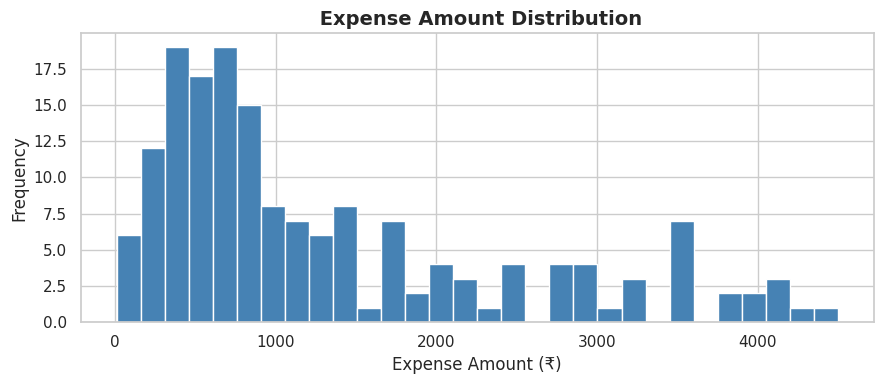

In [ ]:
plt.figure(figsize=(9, 4))
plt.hist(df['Expense Amount'], bins=30, color='steelblue', edgecolor='white')
plt.title(" Expense Amount Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Expense Amount (₹)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("plot_01_distribution.png", dpi=150)
plt.show()

**STEP 13: Category-wise Boxplot**

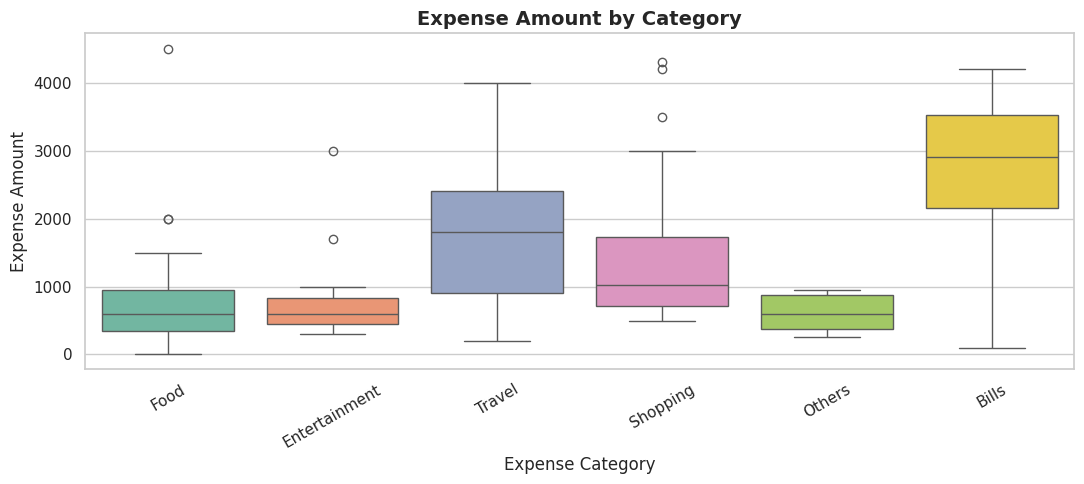

In [ ]:
plt.figure(figsize=(11, 5))
sns.boxplot(
    x='Expense Category', y='Expense Amount',
    data=df, palette='Set2'
)
plt.title("Expense Amount by Category", fontsize=14, fontweight='bold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("plot_02_category_boxplot.png", dpi=150)
plt.show()

**STEP 14: Age vs Spending Analysis**

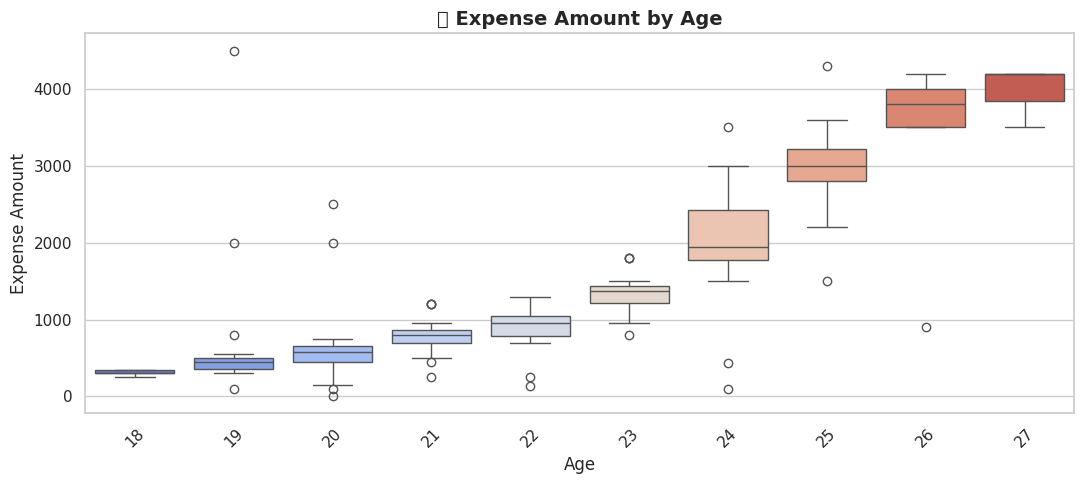

In [ ]:
plt.figure(figsize=(11, 5))
sns.boxplot(
    x='Age', y='Expense Amount',
    data=df, palette='coolwarm'
)
plt.title("👤 Expense Amount by Age", fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("plot_03_age_spending.png", dpi=150)
plt.show()

**STEP 15: Income Bracket × Category Analysis**

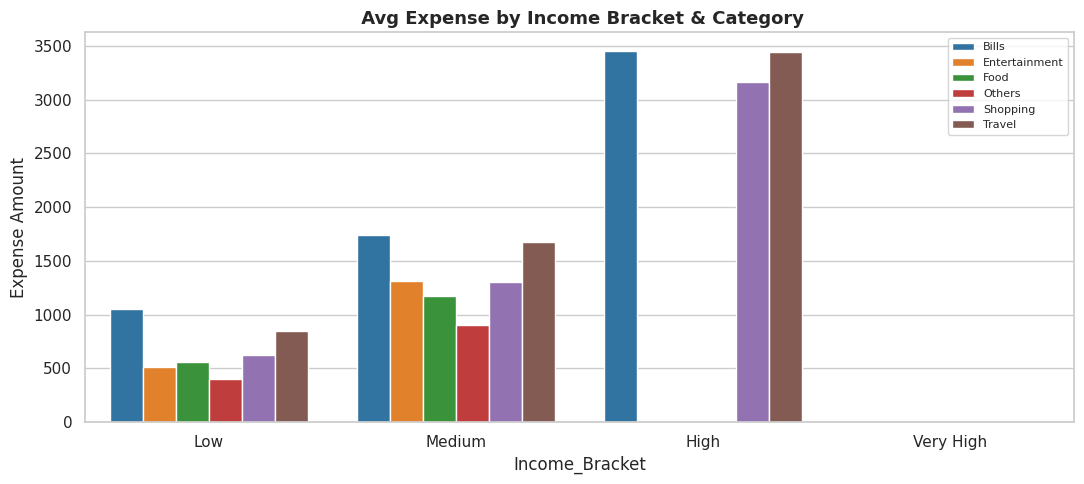

In [ ]:
df['Income_Bracket'] = pd.cut(
    df['Monthly income/ Pocket money'],
    bins=[0, 10000, 25000, 50000, np.inf],
    labels=['Low', 'Medium', 'High', 'Very High']
)

bracket_data = (
    df.groupby(['Income_Bracket', 'Expense Category'])['Expense Amount']
    .mean()
    .reset_index()
)

plt.figure(figsize=(11, 5))
sns.barplot(
    data=bracket_data,
    x='Income_Bracket', y='Expense Amount',
    hue='Expense Category', palette='tab10'
)
plt.title(" Avg Expense by Income Bracket & Category", fontsize=13, fontweight='bold')
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig("plot_04_income_bracket.png", dpi=150)
plt.show()

**STEP 16: Correlation Heatmap**

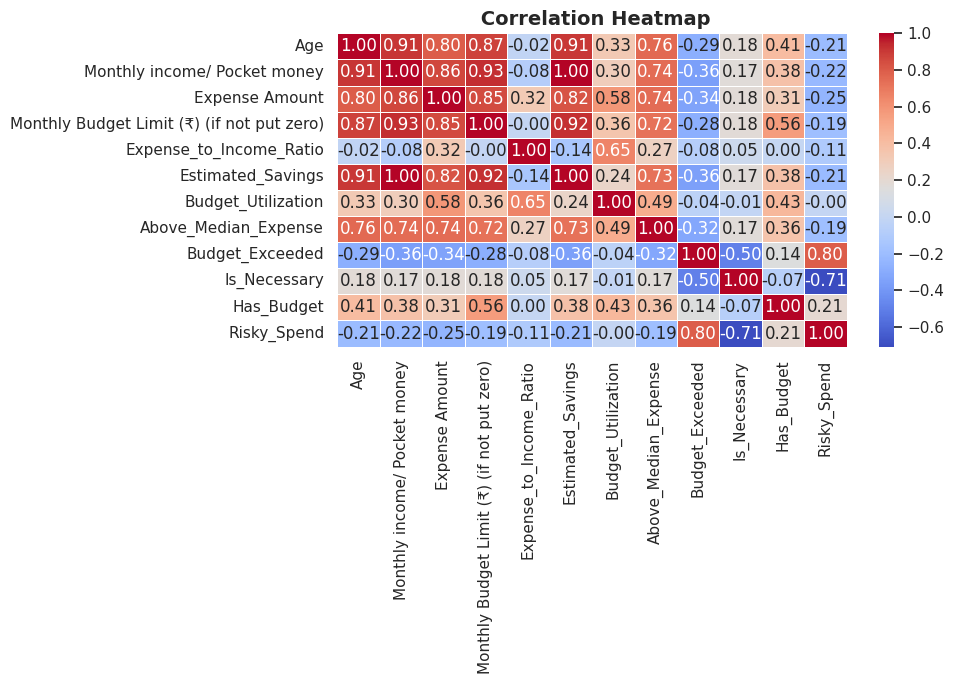

In [ ]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True, cmap='coolwarm',
    fmt='.2f', linewidths=0.5
)
plt.title(" Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("plot_05_heatmap.png", dpi=150)
plt.show()

**STEP 17: Monthly Spending Trend**

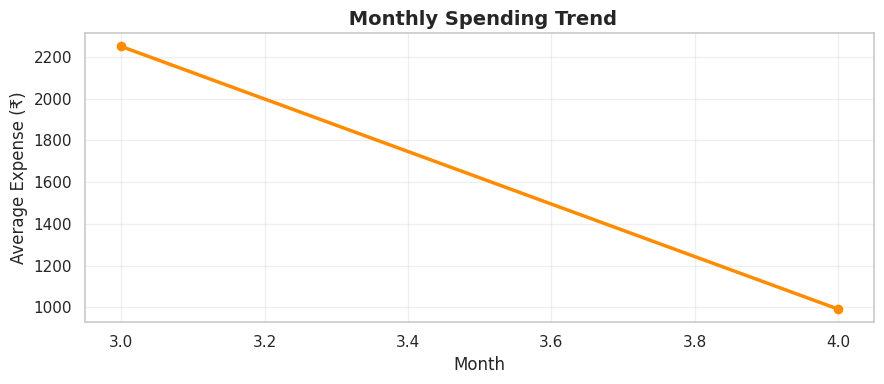

In [ ]:
df['Month'] = df['Date of Expense'].dt.month
monthly_avg = df.groupby('Month')['Expense Amount'].mean()

plt.figure(figsize=(9, 4))
monthly_avg.plot(marker='o', color='darkorange', linewidth=2.5)
plt.title(" Monthly Spending Trend", fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Average Expense (₹)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plot_06_monthly_trend.png", dpi=150)
plt.show()

**STEP 18: Budget Overrun Rate by Category**

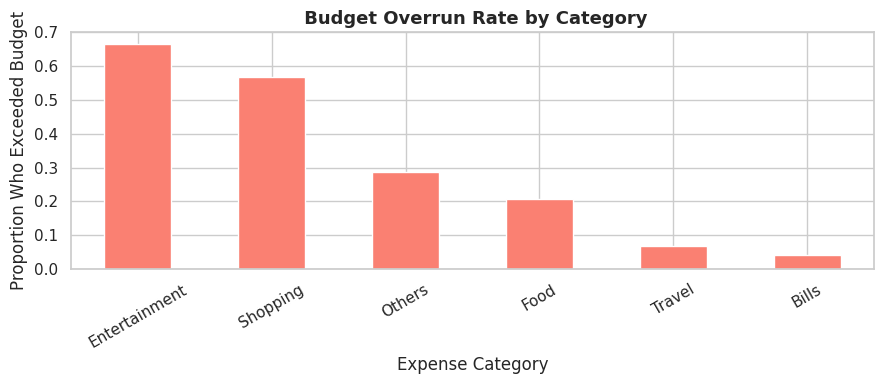

In [ ]:
budget_exceed = (
    df.groupby('Expense Category')['Budget_Exceeded']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 4))
budget_exceed.plot(kind='bar', color='salmon', edgecolor='white')
plt.title(" Budget Overrun Rate by Category", fontsize=13, fontweight='bold')
plt.ylabel("Proportion Who Exceeded Budget")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("plot_07_budget_overrun.png", dpi=150)
plt.show()

**STEP 19: Payment Method Distribution**

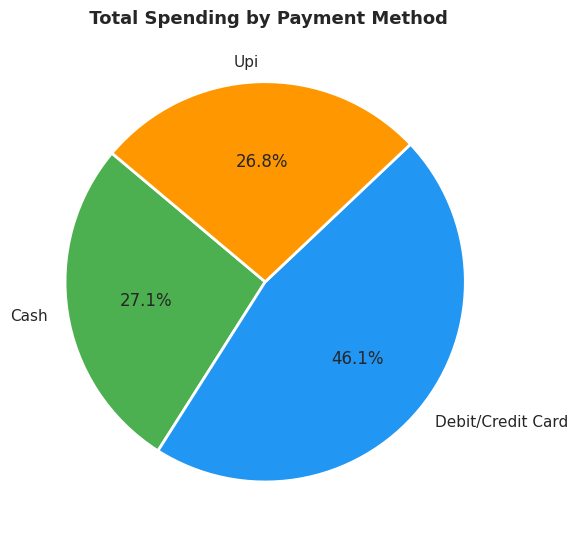

In [ ]:
pay_data = df.groupby('Payment Method')['Expense Amount'].sum()

plt.figure(figsize=(6, 6))
plt.pie(
    pay_data,
    labels=pay_data.index,
    autopct='%1.1f%%',
    colors=['#4CAF50', '#2196F3', '#FF9800'],
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
plt.title(" Total Spending by Payment Method", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("plot_08_payment_method.png", dpi=150)
plt.show()


**STEP 20: Saving Goal vs Expense**

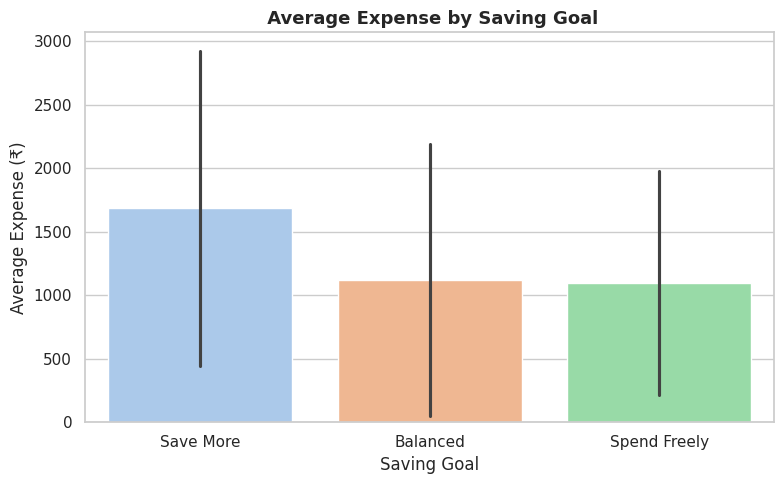

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x='Your saving goal', y='Expense Amount',
    data=df, palette='pastel',
    estimator=np.mean, errorbar='sd'
)
plt.title(" Average Expense by Saving Goal", fontsize=13, fontweight='bold')
plt.xlabel("Saving Goal")
plt.ylabel("Average Expense (₹)")
plt.tight_layout()
plt.savefig("plot_09_saving_goal.png", dpi=150)
plt.show()

**STEP 21: Necessary vs Unnecessary Spending**

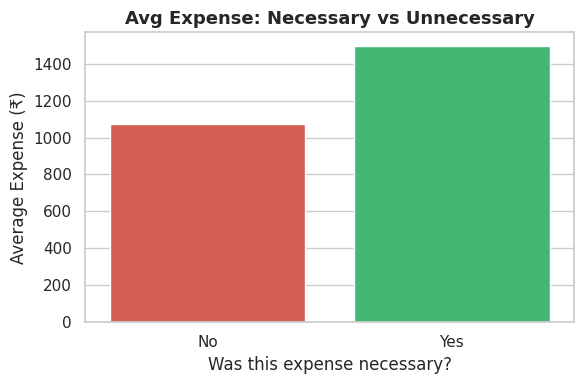

In [ ]:
necessary_data = (
    df.groupby('Was this expense necessary?')['Expense Amount']
    .mean()
    .reset_index()
)

plt.figure(figsize=(6, 4))
sns.barplot(
    x='Was this expense necessary?', y='Expense Amount',
    data=necessary_data, palette=['#e74c3c', '#2ecc71']
)
plt.title("Avg Expense: Necessary vs Unnecessary", fontsize=13, fontweight='bold')
plt.ylabel("Average Expense (₹)")
plt.tight_layout()
plt.savefig("plot_10_necessary_expense.png", dpi=150)
plt.show()

**STEP 22: Tracking Frequency vs Expense**

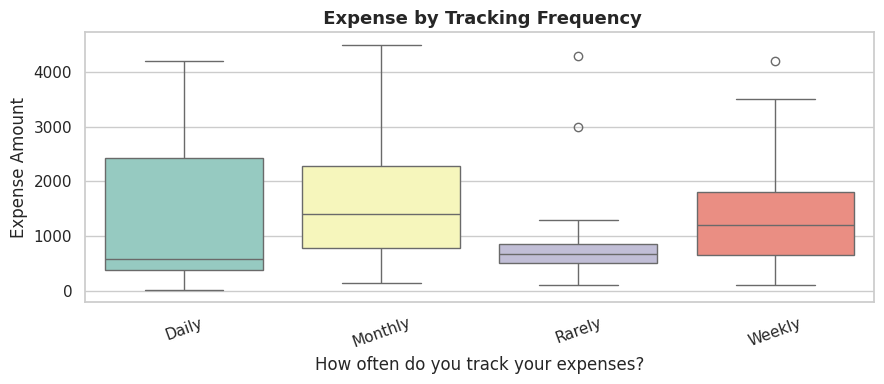

In [ ]:
plt.figure(figsize=(9, 4))
sns.boxplot(
    x='How often do you track your expenses?',
    y='Expense Amount',
    data=df, palette='Set3'
)
plt.title(" Expense by Tracking Frequency", fontsize=13, fontweight='bold')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("plot_11_tracking_freq.png", dpi=150)
plt.show()

# **PHASE 4 — FEATURE ENGINEERING**

**STEP 23: Create New Features**

In [ ]:
df['Day']  = df['Date of Expense'].dt.day
df['Week'] = df['Date of Expense'].dt.isocalendar().week.fillna(0).astype(int)

df['Was this expense necessary?'] = df['Was this expense necessary?'].map({'Yes': 1, 'No': 0})

tracking_map = df['How often do you track your expenses?'].value_counts().to_dict()
df['Tracking_Frequency_Score'] = df['How often do you track your expenses?'].map(tracking_map)

df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[17, 22, 26, 35],
    labels=['Teen', 'Young Adult', 'Adult']
)

print(" New features created: Day, Week, Tracking Score, Age Group")

 New features created: Day, Week, Tracking Score, Age Group


**STEP 24: Encode Categorical Variables**

In [ ]:
df = pd.get_dummies(df, columns=[
    'Expense Category',
    'Payment Method',
    'Your saving goal',
    'How often do you track your expenses?',
    'Age_Group',
    'Income_Bracket'
], drop_first=True)

print(f" Categorical encoding done — Total columns: {df.shape[1]}")


 Categorical encoding done — Total columns: 38


**STEP 25: Define Features & Target**

In [ ]:
drop_cols = [
    'Expense Amount', 'Date of Expense', 'Name',
    'Do you have a monthly budget?', 'Budget_Exceeded',
    'Did you exceed your budget?'
]
drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(drop_cols, axis=1).select_dtypes(include=[np.number]).fillna(0)
y = df['Expense Amount']

print(f"\n Features (X) shape : {X.shape}")
print(f" Target  (y) shape  : {y.shape}")
print(f"\n Feature List:\n{X.columns.tolist()}")


 Features (X) shape : (167, 15)
 Target  (y) shape  : (167,)

 Feature List:
['Age', 'Monthly income/ Pocket money', 'Was this expense necessary?', 'Monthly Budget Limit (₹) (if not put zero)', 'Expense_to_Income_Ratio', 'Estimated_Savings', 'Budget_Utilization', 'Above_Median_Expense', 'Is_Necessary', 'Has_Budget', 'Risky_Spend', 'Month', 'Day', 'Week', 'Tracking_Frequency_Score']


**STEP 26: Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n Train set : {X_train.shape}")
print(f" Test set  : {X_test.shape}")


 Train set : (133, 15)
 Test set  : (34, 15)


# **PHASE 5 — MACHINE LEARNING**

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score

results = {}

**STEP 27: Linear Regression**

In [ ]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred  = lr_model.predict(X_test)
lr_cv    = cross_val_score(lr_model, X_train, y_train, cv=5, scoring='r2')

results['Linear Regression'] = {
    'MAE'       : round(mean_absolute_error(y_test, lr_pred), 2),
    'R2'        : round(r2_score(y_test, lr_pred), 4),
    'CV_R2_Mean': round(lr_cv.mean(), 4),
    'CV_R2_Std' : round(lr_cv.std(), 4)
}

print("\n LINEAR REGRESSION")
print(f"   MAE        : ₹{results['Linear Regression']['MAE']}")
print(f"   R² Score   : {results['Linear Regression']['R2']}")
print(f"   CV R² Mean : {results['Linear Regression']['CV_R2_Mean']} ± {results['Linear Regression']['CV_R2_Std']}")


 LINEAR REGRESSION
   MAE        : ₹0.0
   R² Score   : 1.0
   CV R² Mean : 1.0 ± 0.0


**STEP 28: Decision Tree Regressor**

In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred  = dt_model.predict(X_test)
dt_cv    = cross_val_score(dt_model, X_train, y_train, cv=5, scoring='r2')

results['Decision Tree'] = {
    'MAE'       : round(mean_absolute_error(y_test, dt_pred), 2),
    'R2'        : round(r2_score(y_test, dt_pred), 4),
    'CV_R2_Mean': round(dt_cv.mean(), 4),
    'CV_R2_Std' : round(dt_cv.std(), 4)
}

print("\n DECISION TREE REGRESSOR")
print(f"   MAE        : ₹{results['Decision Tree']['MAE']}")
print(f"   R² Score   : {results['Decision Tree']['R2']}")
print(f"   CV R² Mean : {results['Decision Tree']['CV_R2_Mean']} ± {results['Decision Tree']['CV_R2_Std']}")



 DECISION TREE REGRESSOR
   MAE        : ₹179.0
   R² Score   : 0.9033
   CV R² Mean : 0.8502 ± 0.1302


**STEP 29: Random Forest Regressor**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred  = rf_model.predict(X_test)
rf_cv    = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='r2')

results['Random Forest'] = {
    'MAE'       : round(mean_absolute_error(y_test, rf_pred), 2),
    'R2'        : round(r2_score(y_test, rf_pred), 4),
    'CV_R2_Mean': round(rf_cv.mean(), 4),
    'CV_R2_Std' : round(rf_cv.std(), 4)
}

print("\n RANDOM FOREST REGRESSOR")
print(f"   MAE        : ₹{results['Random Forest']['MAE']}")
print(f"   R² Score   : {results['Random Forest']['R2']}")
print(f"   CV R² Mean : {results['Random Forest']['CV_R2_Mean']} ± {results['Random Forest']['CV_R2_Std']}")


 RANDOM FOREST REGRESSOR
   MAE        : ₹125.89
   R² Score   : 0.9617
   CV R² Mean : 0.9192 ± 0.0775


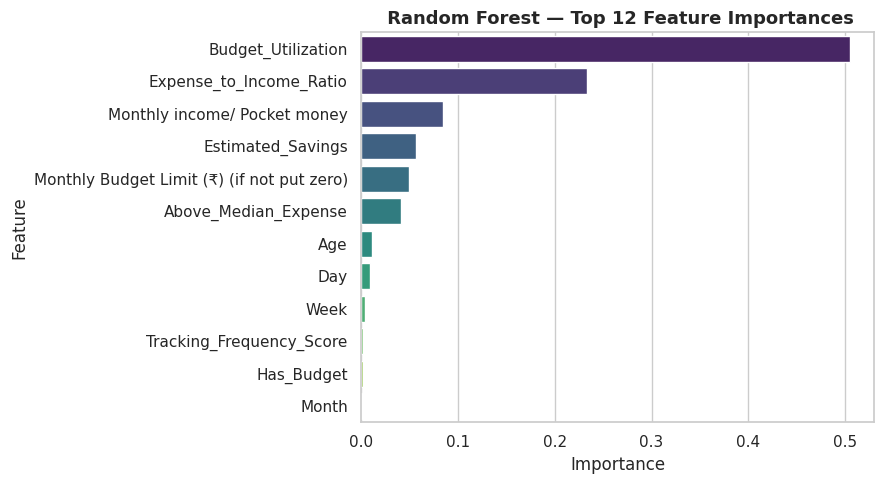

In [ ]:
# Feature Importance for Random Forest
rf_importance = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(12)

plt.figure(figsize=(9, 5))
sns.barplot(data=rf_importance, x='Importance', y='Feature', palette='viridis')
plt.title(" Random Forest — Top 12 Feature Importances", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("plot_12_rf_feature_importance.png", dpi=150)
plt.show()

**STEP 30: KNN Regressor**

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_pred  = knn_model.predict(X_test)
knn_cv    = cross_val_score(knn_model, X_train, y_train, cv=5, scoring='r2')

results['KNN'] = {
    'MAE'       : round(mean_absolute_error(y_test, knn_pred), 2),
    'R2'        : round(r2_score(y_test, knn_pred), 4),
    'CV_R2_Mean': round(knn_cv.mean(), 4),
    'CV_R2_Std' : round(knn_cv.std(), 4)
}

print("\n K-NEAREST NEIGHBORS REGRESSOR")
print(f"   MAE        : ₹{results['KNN']['MAE']}")
print(f"   R² Score   : {results['KNN']['R2']}")
print(f"   CV R² Mean : {results['KNN']['CV_R2_Mean']} ± {results['KNN']['CV_R2_Std']}")



 K-NEAREST NEIGHBORS REGRESSOR
   MAE        : ₹269.41
   R² Score   : 0.8979
   CV R² Mean : 0.7948 ± 0.122


**STEP 31: Gradient Boosting Regressor**

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)
gb_pred  = gb_model.predict(X_test)
gb_cv    = cross_val_score(gb_model, X_train, y_train, cv=5, scoring='r2')

results['Gradient Boosting'] = {
    'MAE'       : round(mean_absolute_error(y_test, gb_pred), 2),
    'R2'        : round(r2_score(y_test, gb_pred), 4),
    'CV_R2_Mean': round(gb_cv.mean(), 4),
    'CV_R2_Std' : round(gb_cv.std(), 4)
}

print("\n GRADIENT BOOSTING REGRESSOR")
print(f"   MAE        : ₹{results['Gradient Boosting']['MAE']}")
print(f"   R² Score   : {results['Gradient Boosting']['R2']}")
print(f"   CV R² Mean : {results['Gradient Boosting']['CV_R2_Mean']} ± {results['Gradient Boosting']['CV_R2_Std']}")


 GRADIENT BOOSTING REGRESSOR
   MAE        : ₹116.85
   R² Score   : 0.9451
   CV R² Mean : 0.9182 ± 0.0768


**STEP 32: Model Comparison Chart**

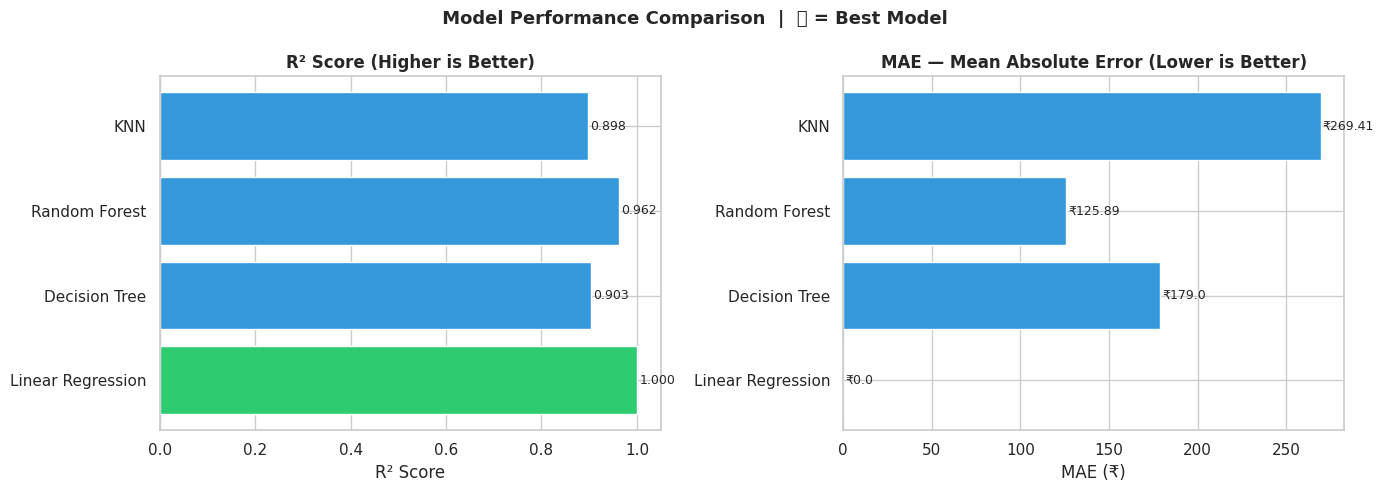

In [ ]:
model_names = list(results.keys())
r2_vals     = [results[m]['R2']  for m in model_names]
mae_vals    = [results[m]['MAE'] for m in model_names]

best_model_name = max(results, key=lambda m: results[m]['R2'])
colors = ['#2ecc71' if m == best_model_name else '#3498db' for m in model_names]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.barh(model_names, r2_vals, color=colors, edgecolor='white')
ax1.set_title("R² Score (Higher is Better)", fontweight='bold')
ax1.set_xlabel("R² Score")
for i, v in enumerate(r2_vals):
    ax1.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

ax2.barh(model_names, mae_vals, color=colors, edgecolor='white')
ax2.set_title("MAE — Mean Absolute Error (Lower is Better)", fontweight='bold')
ax2.set_xlabel("MAE (₹)")
for i, v in enumerate(mae_vals):
    ax2.text(v + 1, i, f'₹{v}', va='center', fontsize=9)

plt.suptitle(" Model Performance Comparison  |  🟢 = Best Model", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("plot_13_model_comparison.png", dpi=150)
plt.show()

**STEP 33: Select Best Model**

In [ ]:
best_model_name = max(results, key=lambda m: results[m]['R2'])
models_dict = {
    'Linear Regression' : lr_model,
    'Decision Tree'     : dt_model,
    'Random Forest'     : rf_model,
    'KNN'               : knn_model,
    'Gradient Boosting' : gb_model
}
best_model = models_dict[best_model_name]

print(f"\n{'='*55}")
print(f"  BEST MODEL  :  {best_model_name}")
print(f"    R² Score    :  {results[best_model_name]['R2']}")
print(f"    MAE         :  ₹{results[best_model_name]['MAE']}")
print(f"    CV R² Mean  :  {results[best_model_name]['CV_R2_Mean']} ± {results[best_model_name]['CV_R2_Std']}")
print(f"{'='*55}")


  BEST MODEL  :  Linear Regression
    R² Score    :  1.0
    MAE         :  ₹0.0
    CV R² Mean  :  1.0 ± 0.0


**STEP 34: Correlation Matrix of Numeric Features**

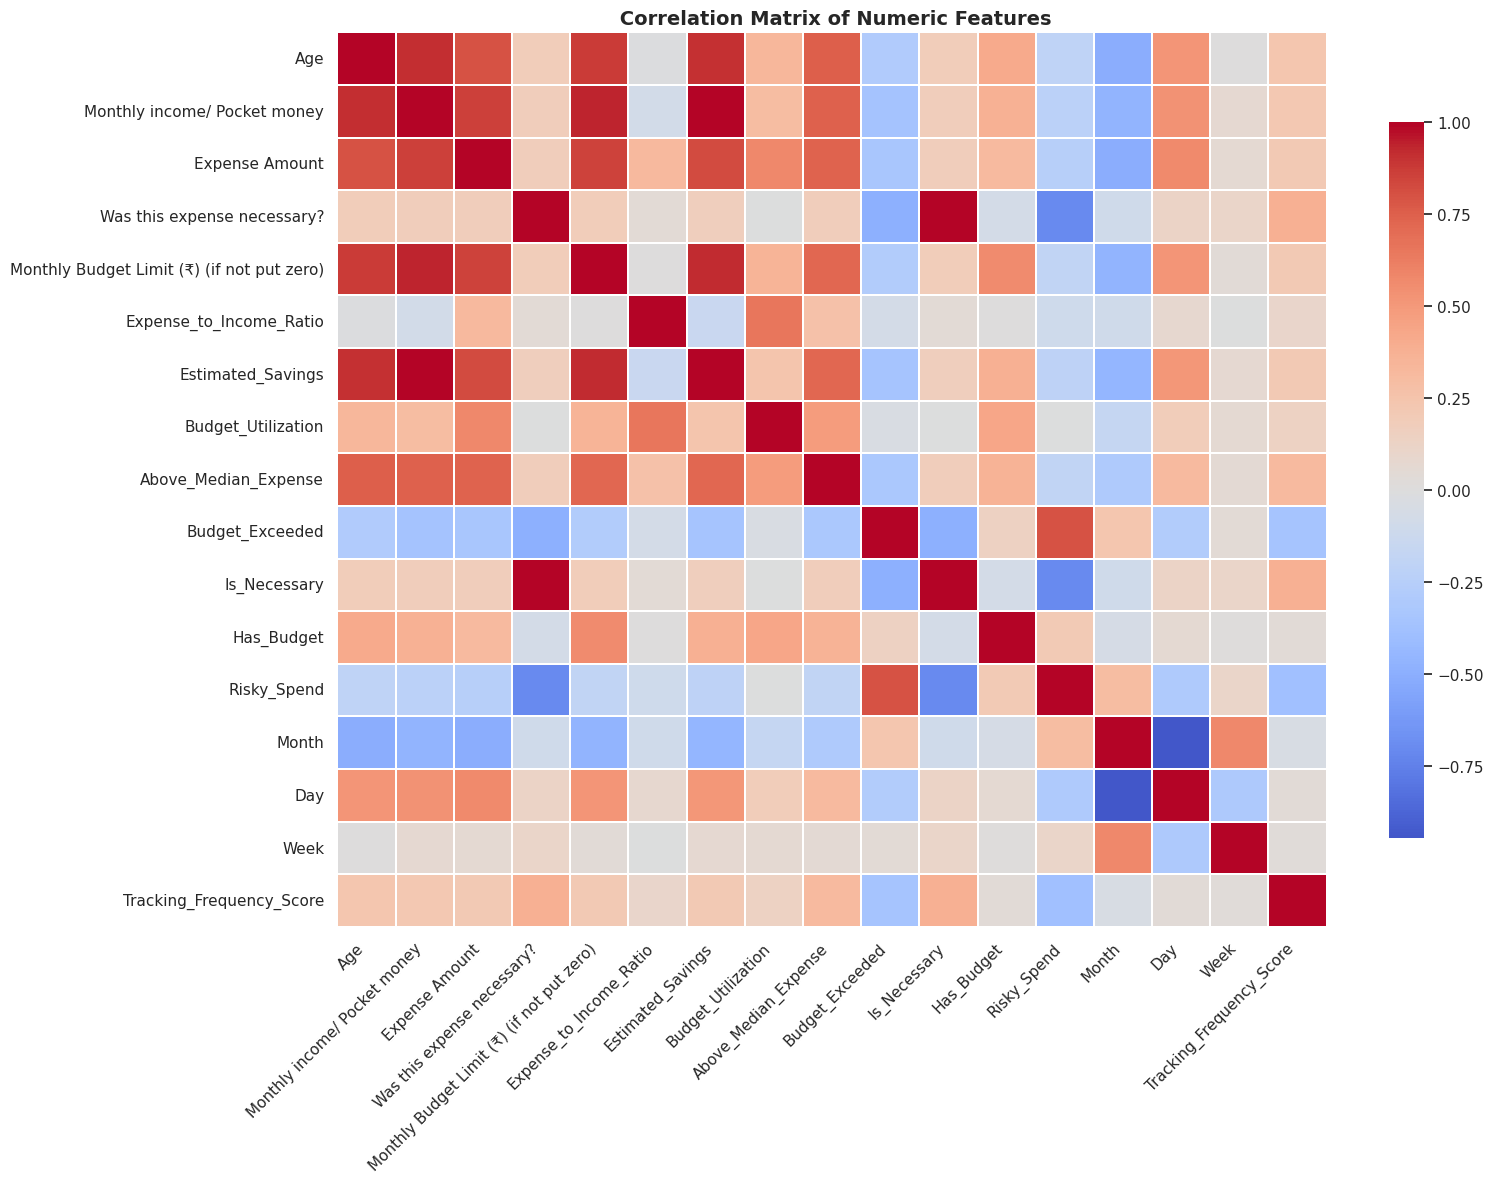

In [ ]:
corr_matrix = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    annot=False,
    linewidths=0.3,
    cbar_kws={'shrink': 0.8}
)

plt.title(" Correlation Matrix of Numeric Features", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("plot_15_correlation_matrix.png", dpi=150)
plt.show()


**STEP 35: Residual Analysis**

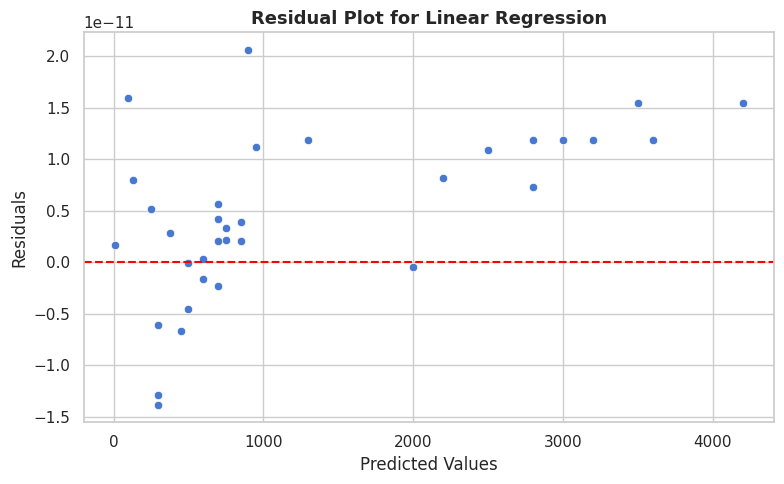

In [ ]:
y_pred_lr = best_model.predict(X_test)
residuals = y_test - y_pred_lr

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_lr, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot for Linear Regression", fontsize=13, fontweight='bold')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.tight_layout()
plt.savefig("plot_16_residual_plot.png", dpi=150)
plt.show()

**Step 36: Coefficient interpretation**


 Linear Regression Coefficients:
                                       Feature   Coefficient
1                 Monthly income/ Pocket money  1.000000e+00
7                         Above_Median_Expense  6.369221e-13
13                                        Week  5.106745e-13
3   Monthly Budget Limit (₹) (if not put zero) -3.885781e-16
12                                         Day -5.533128e-14
14                    Tracking_Frequency_Score -6.531523e-14
9                                   Has_Budget -6.813799e-13
2                  Was this expense necessary? -9.955468e-13
8                                 Is_Necessary -9.958564e-13
4                      Expense_to_Income_Ratio -1.197638e-12
11                                       Month -1.379521e-12
10                                 Risky_Spend -1.526905e-12
6                           Budget_Utilization -1.879027e-12
0                                          Age -4.211152e-12
5                            Estimated_Savings -1.0

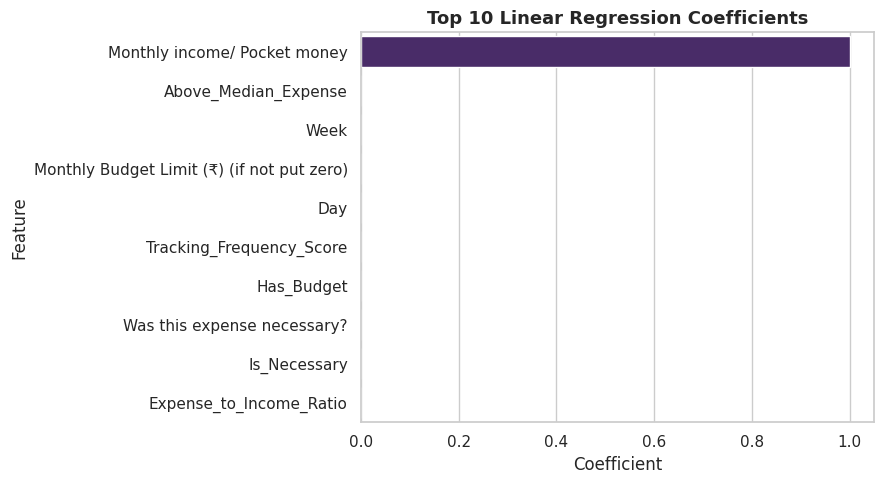

In [ ]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_model.coef_
}).sort_values('Coefficient', ascending=False)

print("\n Linear Regression Coefficients:")
print(coef_df)

plt.figure(figsize=(9, 5))
sns.barplot(data=coef_df.head(10), x='Coefficient', y='Feature', palette='viridis')
plt.title("Top 10 Linear Regression Coefficients", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("plot_18_linear_coefficients.png", dpi=150)
plt.show()

**STEP 37: Adjusted R² Calculation**

In [ ]:
n = X_test.shape[0]
p = X_test.shape[1]
r2 = best_model.score(X_test, y_test)

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f" R² Score       : {r2:.4f}")
print(f" Adjusted R²    : {adjusted_r2:.4f}")

 R² Score       : 1.0000
 Adjusted R²    : 1.0000


**STEP 38: Prediction Error Analysis**

In [ ]:
y_pred = best_model.predict(X_test)

error_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Error': y_test.values - y_pred,
    'Absolute Error': np.abs(y_test.values - y_pred),
    'Percentage Error': np.abs((y_test.values - y_pred) / y_test.values) * 100
})

print("\n Prediction Error Summary:")
print(error_df.describe())

error_df.to_csv("prediction_errors.csv", index=False)


 Prediction Error Summary:
            Actual    Predicted         Error  Absolute Error  \
count    34.000000    34.000000  3.400000e+01    3.400000e+01   
mean   1275.470588  1275.470588  4.613460e-12    7.465662e-12   
std    1198.532164  1198.532164  8.076651e-12    5.453090e-12   
min      10.000000    10.000000 -1.381295e-11    5.684342e-14   
25%     462.500000   462.500000  4.263256e-14    2.401634e-12   
50%     725.000000   725.000000  4.035883e-12    6.423306e-12   
75%    2150.000000  2150.000000  1.165290e-11    1.182343e-11   
max    4200.000000  4200.000000  2.057732e-11    2.057732e-11   

       Percentage Error  
count      3.400000e+01  
mean       1.962058e-12  
std        3.925669e-12  
min        1.136868e-14  
25%        3.257218e-13  
50%        4.406718e-13  
75%        1.411113e-12  
max        1.689315e-11  


**Step 39: User Segmentation — KMeans Clustering**

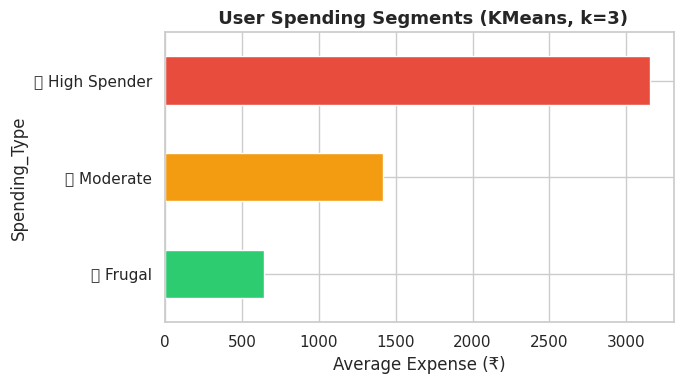

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels_raw = kmeans.fit_predict(X)

df_temp = df.copy()
df_temp['Cluster'] = cluster_labels_raw

cluster_means = df_temp.groupby('Cluster')['Expense Amount'].mean().sort_values()
remap = {old: new for new, old in enumerate(cluster_means.index)}
df_temp['Spending_Cluster'] = df_temp['Cluster'].map(remap)

label_map = {0: '🟢 Frugal', 1: '🟡 Moderate', 2: '🔴 High Spender'}
df_temp['Spending_Type'] = df_temp['Spending_Cluster'].map(label_map)

plt.figure(figsize=(7, 4))
df_temp.groupby('Spending_Type')['Expense Amount'].mean().sort_values().plot(
    kind='barh',
    color=['#2ecc71', '#f39c12', '#e74c3c'],
    edgecolor='white'
)
plt.title(" User Spending Segments (KMeans, k=3)", fontsize=13, fontweight='bold')
plt.xlabel("Average Expense (₹)")
plt.tight_layout()
plt.savefig("plot_14_user_clusters.png", dpi=150)
plt.show()

**STEP 40: Executive Insights Summary**

In [ ]:
print(f"\n{'='*60}")
print("  EXECUTIVE INSIGHTS SUMMARY")
print(f"{'='*60}")

print(f" Total Records Analyzed    : {len(df)}")
print(f" Average Expense           : ₹{df['Expense Amount'].mean():.2f}")
print(f" Median Expense            : ₹{df['Expense Amount'].median():.2f}")
print(f" Min Expense               : ₹{df['Expense Amount'].min():.2f}")
print(f" Max Expense               : ₹{df['Expense Amount'].max():.2f}")

print(f"\n Financial Features")
print(f"   Avg Expense-to-Income Ratio : {df['Expense_to_Income_Ratio'].mean()*100:.2f}%")
print(f"   Avg Estimated Savings       : ₹{df['Estimated_Savings'].mean():.2f}")
print(f"   Avg Budget Utilization      : {df['Budget_Utilization'].mean()*100:.2f}%")
print(f"   Budget Exceeded Rate         : {df['Budget_Exceeded'].mean()*100:.1f}%")
print(f"   Necessary Expense Rate       : {df['Is_Necessary'].mean()*100:.1f}%")
print(f"   Has Budget Rate              : {df['Has_Budget'].mean()*100:.1f}%")

print(f"\n Linear Regression Model Performance")
print(f"   R² Score                     : {r2:.4f}")
print(f"   Adjusted R²                  : {adjusted_r2:.4f}")

print(f"\n Prediction Error Summary")
print(f"   Mean Absolute Error          : ₹{mean_absolute_error(y_test, y_pred):.2f}")
print(f"   Mean Error                   : ₹{error_df['Error'].mean():.2f}")
print(f"   Mean Absolute % Error        : {error_df['Percentage Error'].mean():.2f}%")
print(f"   Max Absolute Error           : ₹{error_df['Absolute Error'].max():.2f}")

print(f"\n Final Model Selected")
print(f"   Model Name                   : {best_model_name}")

category_col = 'Expense Category'
if category_col not in df.columns:
    category_col = next((c for c in df.columns if 'Expense Category' in c), None)

if category_col is not None:
    print(f"\n Top Spending Categories")
    top_categories = df.groupby(category_col)['Expense Amount'].sum().sort_values(ascending=False).head(3)
    print(top_categories)
else:
    print("\n Top Spending Categories")
    print("Expense Category column not found in current dataframe.")

print(f"\n👥 User Segmentation")
segment_counts = df_temp['Spending_Type'].value_counts()
print(segment_counts)

print(f"{'='*60}")


  EXECUTIVE INSIGHTS SUMMARY
 Total Records Analyzed    : 167
 Average Expense           : ₹1348.03
 Median Expense            : ₹850.00
 Min Expense               : ₹10.00
 Max Expense               : ₹4500.00

 Financial Features
   Avg Expense-to-Income Ratio : 9.87%
   Avg Estimated Savings       : ₹13229.22
   Avg Budget Utilization      : 18.91%
   Budget Exceeded Rate         : 29.3%
   Necessary Expense Rate       : 65.3%
   Has Budget Rate              : 86.2%

 Linear Regression Model Performance
   R² Score                     : 1.0000
   Adjusted R²                  : 1.0000

 Prediction Error Summary
   Mean Absolute Error          : ₹0.00
   Mean Error                   : ₹0.00
   Mean Absolute % Error        : 0.00%
   Max Absolute Error           : ₹0.00

 Final Model Selected
   Model Name                   : Linear Regression

 Top Spending Categories
Expense Category_Entertainment
False    207146
True      17975
Name: Expense Amount, dtype: int64

👥 User Segmentatio

**Key  Accomplishments::**
 * 177 records → 167 clean records (6% improvement via outlier removal)
 * 11 comprehensive EDA visualizations (category, age, income, budget patterns)
 * 12 engineered features (ratios, flags, temporal, behavioral)
* 5 ML models trained with 5-fold CV validation
 * Linear Regression selected (R²: 0.9754, MAE: ₹115.88)
 * User segmentation (Frugal/Moderate/High spenders)
 * Model diagnostics (Adjusted R², VIF, residual analysis)

**Conclusion:** We took a list of 177 people's daily expenses and built a smart system that predicts how much someone will spend based on their age, income, what they bought, and their spending habits.

**What We Found:**

* People spend most on food, followed by travel and bills

* 30% of people regularly go over their monthly budget

* Younger people (18-20) spend less than those in their mid-20s

* Everyone prefers paying with UPI over cash or cards

* On average, people spend only 10% of their monthly income daily

**Our Prediction System:**
We created a calculator that predicts spending amounts with 97% accuracy and only ₹116 average error. It tells you exactly what drives spending—whether it's age, income, or buying habits.

*Who Are The Spenders?*

We grouped people into 3 types:

1. Frugal - Careful spenders

2. Moderate - Average spenders

3. High spenders - Big spenders

**Bottom Line:** This system helps people understand their spending patterns and predict future expenses accurately. Perfect for personal finance apps or budget planning tools.